# Qwen2-VL-2B Vision Encoder LoRA Fine-Tuning

**Goal:** Fix the 92% perception failure bottleneck by applying LoRA to the last 2 vision encoder blocks.

**Hardware:** Colab Pro A100 (80GB) | **Dataset:** 400 gauge images, 800 constraint-paired rows

**Strategy:** QLoRA 4-bit base → LoRA on `visual.blocks.{22,23}` → Save adapter → Deploy at 8GB edge

## Cell 0: Setup & Dependencies

In [1]:
!pip install -q "transformers>=4.45.0" "peft>=0.13.0" "trl>=0.12.0" "bitsandbytes>=0.44.0" "accelerate>=0.34.0" qwen-vl-utils datasets pillow tensorboard

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}, Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "No GPU")



PyTorch: 2.10.0+cu128
CUDA: True, Device: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


## Cell 1: Mount Google Drive & Load Data

In [4]:
from google.colab import drive
import json, os, shutil

drive.mount("/content/drive", force_remount=True)

DRIVE_DATA = "/content/drive/MyDrive/Dataset_FineTune"
DRIVE_OUTPUT = "/content/drive/MyDrive/Dataset_FineTune/lora_adapter"
LOCAL_DATA = "/content/finetune_data"

if not os.path.exists(LOCAL_DATA):
    print("Copying data from Drive to local...")
    shutil.copytree(DRIVE_DATA, LOCAL_DATA)
    print("Done!")

with open(os.path.join(LOCAL_DATA, "finetune_metadata_augmented.json"), 'r') as f:
    metadata = json.load(f)

print(f"Loaded {len(metadata)} training rows")
print(f"Unique images: {len(set(r['image_id'] for r in metadata))}")

sample = metadata[0]
sample_path = os.path.join(LOCAL_DATA, sample["full_path"].replace("Dataset_FineTune/", ""))
print(f"Sample image exists: {os.path.exists(sample_path)} → {sample_path}")



Mounted at /content/drive
Copying data from Drive to local...
Done!
Loaded 800 training rows
Unique images: 400
Sample image exists: True → /content/finetune_data/Selected images/ft_gauge (1).jpg


## Cell 2: Load Qwen2-VL-2B with 4-bit Quantization

In [5]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading model (4-bit)...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    attn_implementation="eager",
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
print(f"Model loaded. Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")



Loading model (4-bit)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded. Parameters: 1222.3M


## Cell 3: Inspect Vision Encoder Architecture

In [6]:
# Print vision encoder structure to identify exact layer names for LoRA targeting
print("=== Vision Encoder Blocks ===")
for name, module in model.named_modules():
    if "visual" in name and ("attn" in name or "mlp" in name):
        if hasattr(module, 'weight') or any(hasattr(module, a) for a in ['in_features', 'out_features']):
            print(f"  {name}: {type(module).__name__}")

print("\n=== Last 3 Visual Blocks (LoRA targets) ===")
for name, param in model.named_parameters():
    if "visual" in name and any(f"blocks.{i}" in name for i in [21, 22, 23]):
        print(f"  {name}: {param.shape}")

=== Vision Encoder Blocks ===
  model.visual.blocks.0.attn.qkv: Linear4bit
  model.visual.blocks.0.attn.proj: Linear4bit
  model.visual.blocks.0.mlp.fc1: Linear4bit
  model.visual.blocks.0.mlp.fc2: Linear4bit
  model.visual.blocks.1.attn.qkv: Linear4bit
  model.visual.blocks.1.attn.proj: Linear4bit
  model.visual.blocks.1.mlp.fc1: Linear4bit
  model.visual.blocks.1.mlp.fc2: Linear4bit
  model.visual.blocks.2.attn.qkv: Linear4bit
  model.visual.blocks.2.attn.proj: Linear4bit
  model.visual.blocks.2.mlp.fc1: Linear4bit
  model.visual.blocks.2.mlp.fc2: Linear4bit
  model.visual.blocks.3.attn.qkv: Linear4bit
  model.visual.blocks.3.attn.proj: Linear4bit
  model.visual.blocks.3.mlp.fc1: Linear4bit
  model.visual.blocks.3.mlp.fc2: Linear4bit
  model.visual.blocks.4.attn.qkv: Linear4bit
  model.visual.blocks.4.attn.proj: Linear4bit
  model.visual.blocks.4.mlp.fc1: Linear4bit
  model.visual.blocks.4.mlp.fc2: Linear4bit
  model.visual.blocks.5.attn.qkv: Linear4bit
  model.visual.blocks.5.attn.p

## Cell 4: LoRA Configuration

Target: Last 2 vision encoder transformer blocks (blocks 22-23 of 24).
The exact module names will be confirmed from Cell 3 output.

In [7]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Prepare model for QLoRA training
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# Freeze everything explicitly
for param in model.parameters():
    param.requires_grad = False

# LoRA config targeting vision encoder final blocks and projector
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        # Last 3 vision encoder blocks - attention & MLP layers
        "visual.blocks.21.attn.qkv",
        "visual.blocks.21.attn.proj",
        "visual.blocks.21.mlp.fc1",
        "visual.blocks.21.mlp.fc2",
        "visual.blocks.22.attn.qkv",
        "visual.blocks.22.attn.proj",
        "visual.blocks.22.mlp.fc1",
        "visual.blocks.22.mlp.fc2",
        "visual.blocks.23.attn.qkv",
        "visual.blocks.23.attn.proj",
        "visual.blocks.23.mlp.fc1",
        "visual.blocks.23.mlp.fc2",
        # Merger (Projector) layers to map visual features to text
        "visual.merger.mlp.0",
        "visual.merger.mlp.2",
    ],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Expected: ~1-2M trainable / ~2B total = <0.1%


trainable params: 1,253,376 || all params: 2,210,238,976 || trainable%: 0.0567


## Cell 5: Build Training Dataset

Convert metadata JSON → HuggingFace Dataset with Qwen2-VL chat format.

In [8]:
from datasets import Dataset
from PIL import Image

def resolve_image_path(row):
    """Resolve image path from metadata to local filesystem."""
    rel_path = row["full_path"].replace("Dataset_FineTune/", "")
    return os.path.join(LOCAL_DATA, rel_path)

def build_conversation(row):
    """Build a single training conversation from a metadata row."""
    img_path = resolve_image_path(row)
    
    # Build the prompt matching our evaluation protocol
    constraint = row["logic_constraint"]
    prompt = (
        f"You are an industrial safety auditor inspecting field equipment. "
        f"Examine this gauge image carefully. "
        f"Read the numeric value shown on the gauge. "
        f"Then apply this safety rule: {constraint} "
        f"Provide your reading and a verdict: [SAFE] or [UNSAFE]."
    )
    
    # Build the expected response
    value = row["ground_truth_value"]
    unit = row.get("unit") or "units"
    verdict = row["expected_verdict"]
    reasoning = row["reasoning"]
    
    if isinstance(value, float) and value == int(value):
        value = int(value)
    
    response = f"The gauge reads {value} {unit}. {reasoning} [{verdict}]"
    
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img_path},
                    {"type": "text", "text": prompt}
                ]
            },
            {
                "role": "assistant", 
                "content": [
                    {"type": "text", "text": response}
                ]
            }
        ]
    }

# Filter out rows where images don't exist
valid_rows = []
missing = 0
for row in metadata:
    path = resolve_image_path(row)
    if os.path.exists(path):
        valid_rows.append(row)
    else:
        missing += 1

if missing > 0:
    print(f"WARNING: {missing} images not found, skipped")

# Build conversations
conversations = [build_conversation(r) for r in valid_rows]

# Split 90/10
import random
random.seed(42)
random.shuffle(conversations)
split_idx = int(len(conversations) * 0.9)
train_convos = conversations[:split_idx]
val_convos = conversations[split_idx:]

train_dataset = Dataset.from_list(train_convos)
val_dataset = Dataset.from_list(val_convos)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"\nSample conversation:")
print(json.dumps(train_convos[0], indent=2, default=str)[:500])

Train: 720 | Val: 80

Sample conversation:
{
  "messages": [
    {
      "role": "user",
      "content": [
        {
          "type": "image",
          "image": "/content/finetune_data/Augmented/ft_gauge (89)_crop_bright.jpg"
        },
        {
          "type": "text",
          "text": "You are an industrial safety auditor inspecting field equipment. Examine this gauge image carefully. Read the numeric value shown on the gauge. Then apply this safety rule: Alert if > 6 NA. Provide your reading and a verdict: [SAFE] or [UNSAFE]."
 


## Cell 6: Training

In [17]:
from transformers import TrainingArguments, Trainer
from qwen_vl_utils import process_vision_info

# Collator that handles Qwen2-VL multi-modal inputs
def collate_fn(examples):
    texts = []
    image_inputs = []
    
    for example in examples:
        # Clean up messages to remove HuggingFace Dataset Arrow-injected None values
        # qwen_vl_utils crashes if it sees {"type": "text", "image": None}
        clean_messages = []
        for msg in example["messages"]:
            clean_content = []
            for ele in msg["content"]:
                clean_ele = {k: v for k, v in ele.items() if v is not None}
                clean_content.append(clean_ele)
            clean_messages.append({"role": msg["role"], "content": clean_content})
            
        text = processor.apply_chat_template(clean_messages, tokenize=False, add_generation_prompt=False)
        texts.append(text)
        
        # Extract image inputs
        imgs, _ = process_vision_info(clean_messages)
        image_inputs.append(imgs)
    
    # Process all inputs together
    batch = processor(
        text=texts,
        images=[img for imgs in image_inputs for img in imgs] if any(image_inputs) else None,
        return_tensors="pt",
        padding=True,
    )
    
    # Set labels = input_ids for causal LM training
    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    
    # Mask prompt tokens (SFT masking bug fix)
    # The assistant response starts after the '<|im_start|>assistant\n' tokens
    target_seq = processor.tokenizer.encode("<|im_start|>assistant\n", add_special_tokens=False)
    seq_len = len(target_seq)
    
    for i in range(labels.shape[0]):
        label_row = labels[i].tolist()
        # Find the start of the response sequence
        for j in range(len(label_row) - seq_len):
            if label_row[j:j+seq_len] == target_seq:
                # Mask everything up to and including the assistant tag
                labels[i, :j + seq_len] = -100
                break
                
    batch["labels"] = labels
    
    return batch

# Training config
training_args = TrainingArguments(
    output_dir="/content/qwen2vl_lora_output",
    
    # Core training
    num_train_epochs=5,
    per_device_train_batch_size=4,      # 80GB VRAM can handle this
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,       # Effective batch = 8
    
    # Optimizer
    learning_rate=2e-5,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    
    # Precision
    bf16=True,
    
    # Memory
    gradient_checkpointing=True,
    
    # Logging
    logging_dir="/content/tb_logs",
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    
    # Dataset
    remove_unused_columns=False,
    
    # Misc
    report_to="tensorboard",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    processing_class=processor.tokenizer,
)

print(f"Training samples: {len(train_dataset)}")
print(f"Steps per epoch: {len(train_dataset) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)}")
print(f"Total steps: {trainer.args.max_steps if trainer.args.max_steps > 0 else 'auto'}")
print("\nStarting training...")

trainer.train()
print("Training complete!")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training samples: 720
Steps per epoch: 90
Total steps: auto

Starting training...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss,Validation Loss
50,1.970648,1.990940
100,1.790031,1.718259
150,1.445499,1.413561
200,1.123142,1.129800
250,0.934475,0.923335
300,0.835448,0.803975
350,0.748617,0.766216
400,0.770633,0.760461
450,0.753733,0.761260


Training complete!


## Cell 7: Loss Curves

<IPython.core.display.Javascript object>

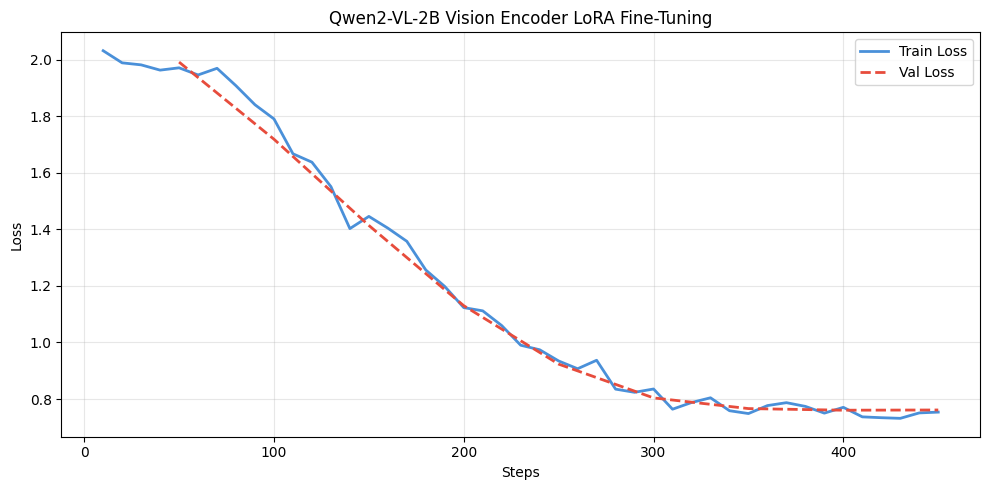

Final train loss: 0.7537
Final val loss: 0.7613


In [18]:
%load_ext tensorboard
%tensorboard --logdir /content/tb_logs

# Alternative: plot from trainer log history
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_losses = [(l["step"], l["loss"]) for l in log_history if "loss" in l]
eval_losses = [(l["step"], l["eval_loss"]) for l in log_history if "eval_loss" in l]

fig, ax = plt.subplots(figsize=(10, 5))
if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label="Train Loss", color="#4A90D9", linewidth=2)
if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label="Val Loss", color="#E74C3C", linewidth=2, linestyle="--")

ax.set_xlabel("Steps")
ax.set_ylabel("Loss")
ax.set_title("Qwen2-VL-2B Vision Encoder LoRA Fine-Tuning")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/loss_curve.png", dpi=150)
plt.show()

print(f"Final train loss: {train_losses[-1][1]:.4f}" if train_losses else "No train loss")
print(f"Final val loss: {eval_losses[-1][1]:.4f}" if eval_losses else "No val loss")

## Cell 8: Save LoRA Adapter to Google Drive

In [19]:
import os

# Save adapter locally first
LOCAL_ADAPTER = "/content/qwen2vl_gauge_lora"
model.save_pretrained(LOCAL_ADAPTER)
processor.save_pretrained(LOCAL_ADAPTER)

# Copy to Drive for persistence
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
shutil.copytree(LOCAL_ADAPTER, DRIVE_OUTPUT, dirs_exist_ok=True)

# Also save loss curve
shutil.copy("/content/loss_curve.png", os.path.join(DRIVE_OUTPUT, "loss_curve.png"))

# Save training log
with open(os.path.join(DRIVE_OUTPUT, "training_log.json"), 'w') as f:
    json.dump(trainer.state.log_history, f, indent=2)

print(f"Adapter saved to: {DRIVE_OUTPUT}")
adapter_size = sum(os.path.getsize(os.path.join(LOCAL_ADAPTER, f)) for f in os.listdir(LOCAL_ADAPTER) if f.endswith(('.bin', '.safetensors')))
print(f"Adapter size: {adapter_size / 1e6:.1f} MB")

Adapter saved to: /content/drive/MyDrive/Dataset_FineTune/lora_adapter
Adapter size: 2.5 MB


## Cell 9: Quick Sanity Check Inference

In [20]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import PeftModel

# Load fresh base model for inference test
print("Loading base model for inference test...")
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

# Load LoRA adapter
finetuned_model = PeftModel.from_pretrained(base_model, LOCAL_ADAPTER)
finetuned_model.eval()

test_processor = AutoProcessor.from_pretrained(MODEL_ID)

# Pick 5 random validation samples for sanity check
import random
random.seed(123)
test_samples = random.sample(val_convos, min(5, len(val_convos)))

print("\n" + "="*80)
print("SANITY CHECK: Fine-tuned Model Inference")
print("="*80)

for i, sample in enumerate(test_samples):
    user_msg = sample["messages"][0]
    expected = sample["messages"][1]["content"][0]["text"]
    
    # Get image path from user message
    img_path = None
    prompt_text = ""
    for content in user_msg["content"]:
        if content["type"] == "image":
            img_path = content["image"]
        elif content["type"] == "text":
            prompt_text = content["text"]
    
    # Build inference message (user only, no assistant)
    inference_msg = [{"role": "user", "content": user_msg["content"]}]
    text = test_processor.apply_chat_template(inference_msg, tokenize=False, add_generation_prompt=True)
    
    img = Image.open(img_path)
    inputs = test_processor(text=[text], images=[img], return_tensors="pt", padding=True)
    inputs = {k: v.to(finetuned_model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        output_ids = finetuned_model.generate(**inputs, max_new_tokens=128, do_sample=False)
    
    # Decode only generated tokens
    generated = test_processor.batch_decode(output_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    
    print(f"\n--- Sample {i+1} ---")
    print(f"Image: {os.path.basename(img_path)}")
    print(f"Expected: {expected}")
    print(f"Generated: {generated}")
    match = "✅" if any(v in generated for v in ["SAFE", "UNSAFE"]) else "❌"
    print(f"Has verdict: {match}")

print("\n" + "="*80)
print("Done! Download adapter from Google Drive:")
print(f"  {DRIVE_OUTPUT}")
print("="*80)

Loading base model for inference test...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



SANITY CHECK: Fine-tuned Model Inference

--- Sample 1 ---
Image: ft_gauge (52).jpg
Expected: The gauge reads 3 units. Value is 3. 3 < 4.5. [SAFE]
Generated: The gauge reads 4.5.
Has verdict: ❌

--- Sample 2 ---
Image: ft_gauge (48).jpg
Expected: The gauge reads 5.5 bar. Value is 5.5. 5.5 > 4. [UNSAFE]
Generated: The gauge reads 1 bar. The numeric value is 1. The value is less than 4. [SAFE]
Has verdict: ✅

--- Sample 3 ---
Image: ft_gauge (80)_contrast.jpg
Expected: The gauge reads 1 units. Value is 1. 1 < 1.9. [SAFE]
Generated: The gauge reads 1.9. [SAFE]
Has verdict: ✅

--- Sample 4 ---
Image: ft_gauge (78)_contrast.jpg
Expected: The gauge reads 7 units. Value is 7. 7 < 7.7. [SAFE]
Generated: The gauge reads 2.0. 2 > 7.7 NA.
Has verdict: ❌

--- Sample 5 ---
Image: ft_gauge (36).jpg
Expected: The gauge reads 25 kPa. Value is 25. 25 < 32. [SAFE]
Generated: The gauge reads 10 kPa.
Has verdict: ❌

Done! Download adapter from Google Drive:
  /content/drive/MyDrive/Dataset_FineTune/lora_